# Eswatini CDI — NDMC Regional Percentiles Validation

**Purpose**: This notebook validates the project team's interpretation and processing of the new NDMC Regional Percentiles GeoTIFFs for the Eswatini Combined Drought Indicator (CDI).

**Shared with**: NDMC team for technical review before production deployment.

**Data source**: https://droughtcenter.unl.edu/Outgoing/Regional_Percentiles/Southern_Africa/ (public, no credentials needed)

---

### New indices used

| CDI Component | Old source | New source | NDMC directory |
|---|---|---|---|
| Thermal stress | MODIS LST (MOD21C3, HDF) | **ESI** — Evaporative Stress Index | `era5_esi_1mn` |
| Vegetation health | MODIS NDVI (MOD13C2, HDF) | **EVI2** — 2-Band Enhanced Vegetation Index | `evi2_1mn` |
| Precipitation | CHIRPS (raw download + SPI) | **SPI 3-month** pre-ranked | `chirps_spi_3mn` |
| Soil moisture | FLDAS (NASA Earthdata) | **NOAH soil moisture** | `noah_soilm_1mn` |

### Questions for NDMC to validate
- Is our interpretation of the value range (0–100 percentile) correct?
- Is NoData = -1 the correct mask value?
- Are the CDI weights (ESI 0.3 / EVI2 0.3 / SPI 0.3 / SM 0.1) a reasonable starting point?
- Do the output maps look geographically plausible?

## 0. Setup

In [1]:
# Install required packages (Colab has numpy/matplotlib pre-installed)
!pip install -q rasterio netCDF4 scipy


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import re
import urllib.request
from datetime import date
from pathlib import Path

import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
from rasterio.windows import from_bounds

# ── Eswatini bounding box (from cdi_project_settings.conf) ──────────────────
ESWATINI = {
    'n_lat': -25.675,
    's_lat': -27.825,
    'w_lon':  30.675,
    'e_lon':  32.825,
}

# ── NDMC endpoint ────────────────────────────────────────────────────────────
NDMC_BASE = 'https://droughtcenter.unl.edu/Outgoing/Regional_Percentiles/Southern_Africa'

DATASETS = {
    'esi':  'era5_esi_1mn',
    'evi2': 'evi2_1mn',
    'spi':  'chirps_spi_3mn',
    'sm':   'noah_soilm_1mn',
}

# ── CDI weights (sum must equal 1.0) ─────────────────────────────────────────
CDI_WEIGHTS = {
    'esi':  0.30,
    'evi2': 0.30,
    'spi':  0.30,
    'sm':   0.10,
}

NODATA_NDMC    = -1.0      # nodata value in NDMC files
NODATA_INTERNAL = -9999.0  # internal missing value

DATA_DIR = Path('/tmp/ndmc_validation')
DATA_DIR.mkdir(exist_ok=True)

print('Setup complete.')
print(f'CDI weight sum: {sum(CDI_WEIGHTS.values())} (must be 1.0)')

Setup complete.
CDI weight sum: 1.0 (must be 1.0)


## 1. Explore NDMC Data

Download one sample file per dataset and inspect its properties.

In [3]:
def download_file(dataset_key, year, month):
    """Download one NDMC GeoTIFF. Returns local path."""
    ds = DATASETS[dataset_key]
    filename = f'{ds}_{year}-{month:02d}-01.tif'
    url = f'{NDMC_BASE}/{ds}/{year}/{filename}'
    local = DATA_DIR / dataset_key / filename
    local.parent.mkdir(exist_ok=True)
    if not local.exists():
        print(f'  Downloading {filename}...')
        urllib.request.urlretrieve(url, local)
    return local


# Download the latest available month for each dataset
SAMPLE_YEAR, SAMPLE_MONTH = 2026, 4
sample_files = {}
for key in DATASETS:
    try:
        sample_files[key] = download_file(key, SAMPLE_YEAR, SAMPLE_MONTH)
        print(f'[{key.upper():4s}] OK — {sample_files[key].name}')
    except Exception as e:
        # EVI2 may start one month later
        try:
            sample_files[key] = download_file(key, SAMPLE_YEAR, SAMPLE_MONTH - 1)
            print(f'[{key.upper():4s}] OK — {sample_files[key].name} (one month earlier)')
        except Exception as e2:
            print(f'[{key.upper():4s}] FAILED: {e2}')

[ESI ] OK — era5_esi_1mn_2026-04-01.tif
[EVI2] OK — evi2_1mn_2026-04-01.tif
[SPI ] OK — chirps_spi_3mn_2026-04-01.tif
[SM  ] OK — noah_soilm_1mn_2026-04-01.tif


In [4]:
# Inspect properties of each sample file
print(f'{"Dataset":<8} {"Shape":>14} {"CRS":>12} {"Pixel":>8} {"Min":>8} {"Max":>8} {"NoData":>8} {"Valid%":>8}')
print('-' * 76)

for key, path in sample_files.items():
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        valid = data[data != NODATA_NDMC]
        crs_code = src.crs.to_epsg() if src.crs else 'N/A'
        res = src.res[0]
        valid_pct = 100 * len(valid) / data.size
        print(
            f'{key.upper():<8} '
            f'{str(data.shape):>14} '
            f'EPSG:{crs_code:>6} '
            f'{res:>8.3f}° '
            f'{valid.min():>8.3f} '
            f'{valid.max():>8.3f} '
            f'{NODATA_NDMC:>8.0f} '
            f'{valid_pct:>7.1f}%'
        )

Dataset           Shape          CRS    Pixel      Min      Max   NoData   Valid%
----------------------------------------------------------------------------
ESI          (360, 620) EPSG:  4326    0.050°    0.135   99.865       -1    52.7%
EVI2         (360, 620) EPSG:  4326    0.050°    0.001   99.996       -1    52.7%
SPI          (360, 620) EPSG:  4326    0.050°    0.000   99.906       -1    52.7%
SM           (360, 620) EPSG:  4326    0.050°    2.032   99.999       -1    52.7%


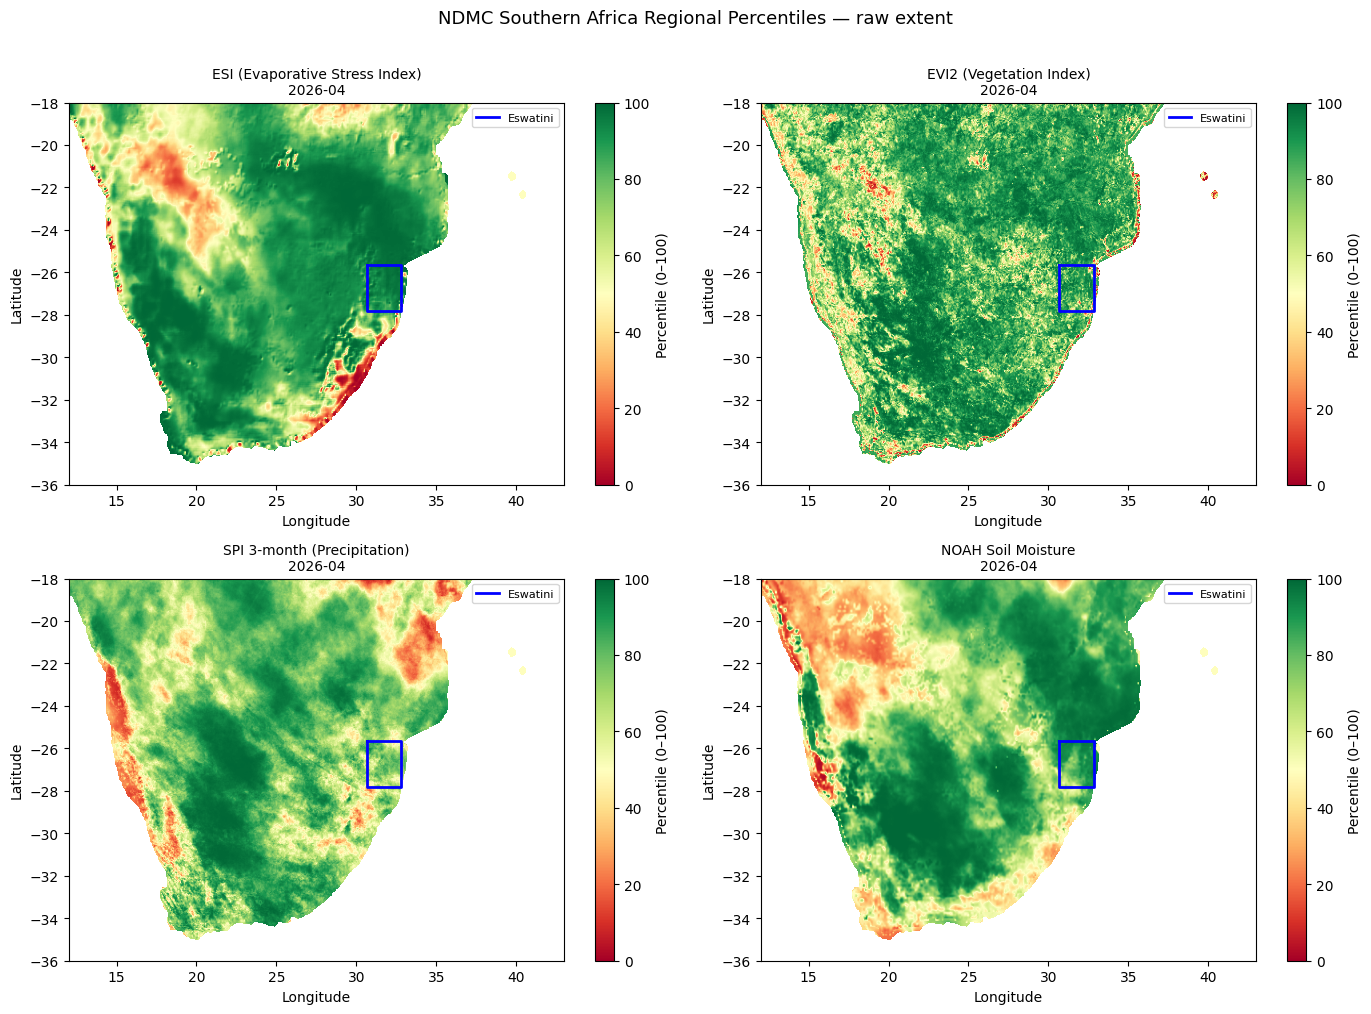

In [5]:
# Visualise all 4 datasets at Southern Africa extent (before clipping)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
labels = {'esi': 'ESI (Evaporative Stress Index)',
          'evi2': 'EVI2 (Vegetation Index)',
          'spi': 'SPI 3-month (Precipitation)',
          'sm': 'NOAH Soil Moisture'}

for ax, (key, path) in zip(axes.flat, sample_files.items()):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        bounds = src.bounds
    masked = ma.masked_equal(data, NODATA_NDMC)
    im = ax.imshow(
        masked, vmin=0, vmax=100, cmap='RdYlGn',
        extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
        origin='upper', aspect='auto'
    )
    # Mark Eswatini location
    ax.plot(
        [ESWATINI['w_lon'], ESWATINI['e_lon'], ESWATINI['e_lon'],
         ESWATINI['w_lon'], ESWATINI['w_lon']],
        [ESWATINI['n_lat'], ESWATINI['n_lat'], ESWATINI['s_lat'],
         ESWATINI['s_lat'], ESWATINI['n_lat']],
        'b-', linewidth=2, label='Eswatini'
    )
    ax.legend(fontsize=8)
    ax.set_title(f'{labels[key]}\n{SAMPLE_YEAR}-{SAMPLE_MONTH:02d}', fontsize=10)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.colorbar(im, ax=ax, label='Percentile (0–100)')

plt.suptitle('NDMC Southern Africa Regional Percentiles — raw extent', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 2. Clip to Eswatini

The NDMC files cover all of Southern Africa. We clip to the Eswatini bounding box
before CDI computation.

In [6]:
def clip_to_eswatini(tif_path):
    """Clip a GeoTIFF to Eswatini, apply nodata mask, scale 0-100 → 0-1.

    Returns (clipped_array, transform, shape) where:
    - clipped_array: masked numpy array, values 0-1, missing=-9999
    - transform: rasterio Affine transform for the clip
    """
    with rasterio.open(tif_path) as src:
        window = from_bounds(
            ESWATINI['w_lon'], ESWATINI['s_lat'],
            ESWATINI['e_lon'], ESWATINI['n_lat'],
            src.transform
        )
        data = src.read(1, window=window).astype(float)
        transform = src.window_transform(window)

    # Mask nodata and scale
    data[data == NODATA_NDMC] = NODATA_INTERNAL
    valid_mask = data != NODATA_INTERNAL
    data[valid_mask] = data[valid_mask] / 100.0  # 0-100 → 0-1

    return ma.masked_equal(data, NODATA_INTERNAL), transform


# Test clip for each dataset
clipped = {}
transforms = {}
for key, path in sample_files.items():
    arr, tfm = clip_to_eswatini(path)
    clipped[key] = arr
    transforms[key] = tfm
    valid = arr.compressed()
    print(f'[{key.upper():4s}] shape={arr.shape}  min={valid.min():.3f}  max={valid.max():.3f}  '
          f'mean={valid.mean():.3f}  valid_pixels={len(valid)}/{arr.size}')

[ESI ] shape=(43, 43)  min=0.003  max=0.996  mean=0.928  valid_pixels=1849/1849
[EVI2] shape=(43, 43)  min=0.005  max=0.999  mean=0.821  valid_pixels=1849/1849
[SPI ] shape=(43, 43)  min=0.382  max=0.942  mean=0.707  valid_pixels=1849/1849
[SM  ] shape=(43, 43)  min=0.532  max=0.968  mean=0.852  valid_pixels=1849/1849


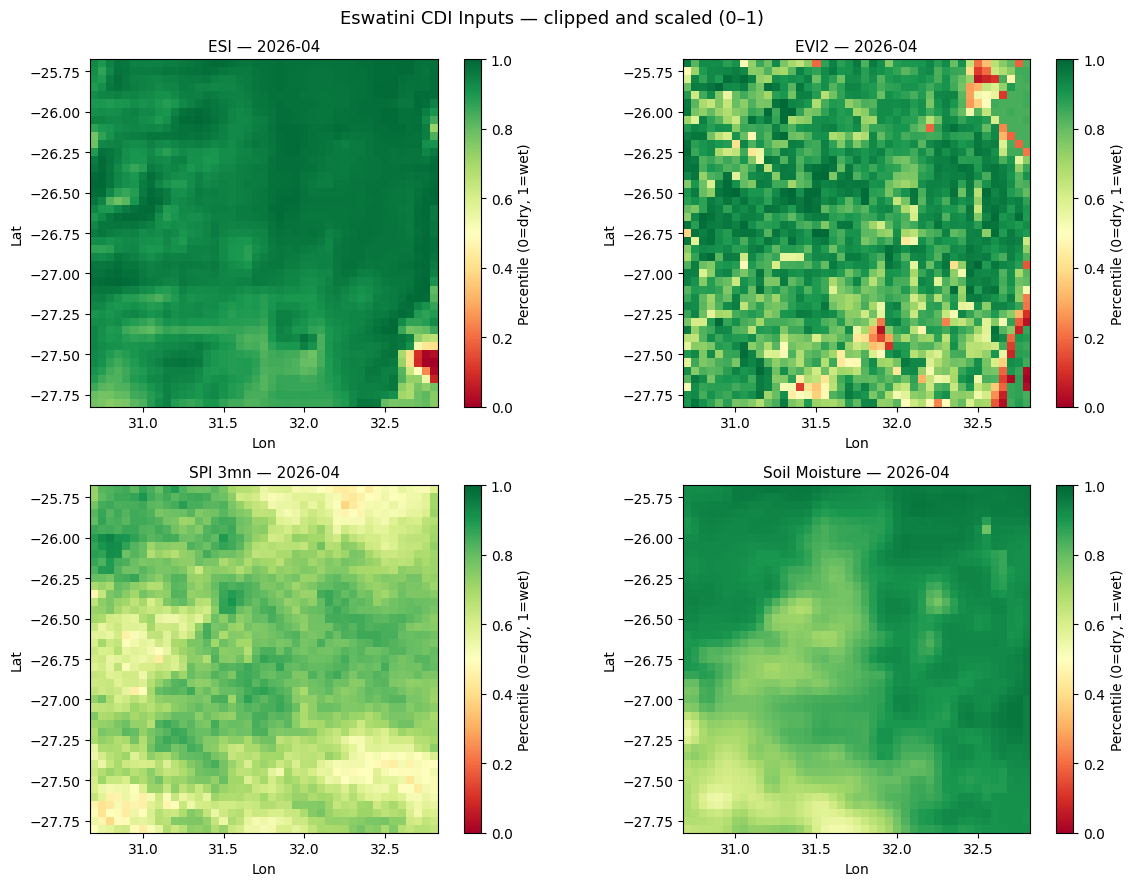

In [7]:
# Visualise clipped datasets side by side
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
short = {'esi': 'ESI', 'evi2': 'EVI2', 'spi': 'SPI 3mn', 'sm': 'Soil Moisture'}

for ax, key in zip(axes.flat, clipped):
    arr = clipped[key]
    tfm = transforms[key]
    left = tfm.c
    top  = tfm.f
    right = left + tfm.a * arr.shape[1]
    bottom = top + tfm.e * arr.shape[0]
    im = ax.imshow(
        arr, vmin=0, vmax=1, cmap='RdYlGn',
        extent=[left, right, bottom, top],
        origin='upper', aspect='equal'
    )
    ax.set_title(f'{short[key]} — {SAMPLE_YEAR}-{SAMPLE_MONTH:02d}', fontsize=11)
    ax.set_xlabel('Lon')
    ax.set_ylabel('Lat')
    plt.colorbar(im, ax=ax, label='Percentile (0=dry, 1=wet)')

plt.suptitle('Eswatini CDI Inputs — clipped and scaled (0–1)', fontsize=13)
plt.tight_layout()
plt.show()

## 3. CDI Weighted Sum

The CDI is computed as a weighted sum of the four percentile-ranked inputs.
A **lower** CDI value indicates **drier** conditions.

Proposed weights for NDMC review:

| Index | Weight | Rationale |
|-------|--------|-----------|
| ESI   | 0.30   | Same weight as previous LST |
| EVI2  | 0.30   | Same weight as previous NDVI |
| SPI 3mn | 0.30 | Slightly reduced from 0.40 to accommodate SM |
| SM    | 0.10   | New — enabled now that NDMC provides pre-ranked data |

In [8]:
def compute_cdi_weighted_sum(clipped_arrays, weights):
    """Compute weighted sum CDI from a dict of masked arrays.

    All arrays must have the same shape.
    Returns masked array; missing where ANY input is missing.
    """
    shape = next(iter(clipped_arrays.values())).shape
    cdi = np.zeros(shape)
    valid = np.ones(shape, dtype=bool)

    for key, arr in clipped_arrays.items():
        valid &= ~arr.mask if hasattr(arr, 'mask') else np.ones(shape, bool)
        cdi += arr.filled(0.0) * weights[key]

    return ma.masked_where(~valid, cdi)


cdi = compute_cdi_weighted_sum(clipped, CDI_WEIGHTS)
valid_cdi = cdi.compressed()
print(f'CDI  min={valid_cdi.min():.3f}  max={valid_cdi.max():.3f}  mean={valid_cdi.mean():.3f}')
print(f'     valid pixels: {len(valid_cdi)}/{cdi.size}')
print(f'     Interpretation: 0=extremely dry  0.5=normal  1=extremely wet')

CDI  min=0.264  max=0.938  mean=0.822
     valid pixels: 1849/1849
     Interpretation: 0=extremely dry  0.5=normal  1=extremely wet


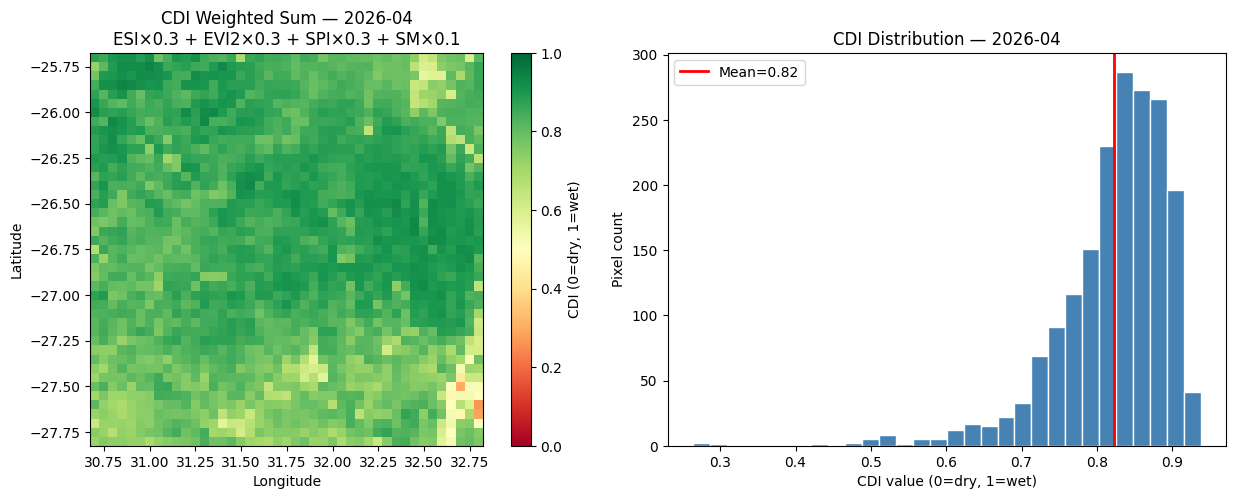

In [9]:
# Visualise CDI alongside individual inputs
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

tfm = transforms['esi']  # all clips share same extent
left   = tfm.c
top    = tfm.f
right  = left + tfm.a * cdi.shape[1]
bottom = top  + tfm.e * cdi.shape[0]
extent = [left, right, bottom, top]

# CDI map
ax = axes[0]
im = ax.imshow(cdi, vmin=0, vmax=1, cmap='RdYlGn',
               extent=extent, origin='upper', aspect='equal')
ax.set_title(f'CDI Weighted Sum — {SAMPLE_YEAR}-{SAMPLE_MONTH:02d}\n'
             f'ESI×{CDI_WEIGHTS["esi"]} + EVI2×{CDI_WEIGHTS["evi2"]} + '
             f'SPI×{CDI_WEIGHTS["spi"]} + SM×{CDI_WEIGHTS["sm"]}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.colorbar(im, ax=ax, label='CDI (0=dry, 1=wet)')

# Histogram of CDI values
ax = axes[1]
ax.hist(valid_cdi, bins=30, color='steelblue', edgecolor='white')
ax.axvline(valid_cdi.mean(), color='red', linewidth=2, label=f'Mean={valid_cdi.mean():.2f}')
ax.set_xlabel('CDI value (0=dry, 1=wet)')
ax.set_ylabel('Pixel count')
ax.set_title(f'CDI Distribution — {SAMPLE_YEAR}-{SAMPLE_MONTH:02d}')
ax.legend()

plt.tight_layout()
plt.show()

## 4. Multi-Month Time Series

Download the available 2026 months for each dataset and show CDI evolution.

In [10]:
# Download all available 2026 months for each dataset
YEAR = 2026
MONTHS = range(1, 5)  # Jan–Apr 2026 (update if more become available)

monthly_cdi = {}  # {(year, month): cdi_array}

for month in MONTHS:
    monthly_clipped = {}
    all_ok = True
    for key in DATASETS:
        try:
            path = download_file(key, YEAR, month)
            arr, _ = clip_to_eswatini(path)
            monthly_clipped[key] = arr
        except Exception as e:
            print(f'  [{key.upper()}] {YEAR}-{month:02d}: {e} — skipping')
            all_ok = False
            break
    if all_ok:
        monthly_cdi[(YEAR, month)] = compute_cdi_weighted_sum(monthly_clipped, CDI_WEIGHTS)
        means = {k: round(float(monthly_clipped[k].mean()), 3) for k in monthly_clipped}
        print(f'{YEAR}-{month:02d}  CDI={monthly_cdi[(YEAR,month)].mean():.3f}  inputs={means}')

print(f'\n{len(monthly_cdi)} months processed.')

  [EVI2] 2026-01: HTTP Error 404: Not Found — skipping
2026-02  CDI=0.538  inputs={'esi': 0.285, 'evi2': 0.784, 'spi': 0.441, 'sm': 0.843}
2026-03  CDI=0.735  inputs={'esi': 0.891, 'evi2': 0.73, 'spi': 0.58, 'sm': 0.747}
2026-04  CDI=0.822  inputs={'esi': 0.928, 'evi2': 0.821, 'spi': 0.707, 'sm': 0.852}

3 months processed.


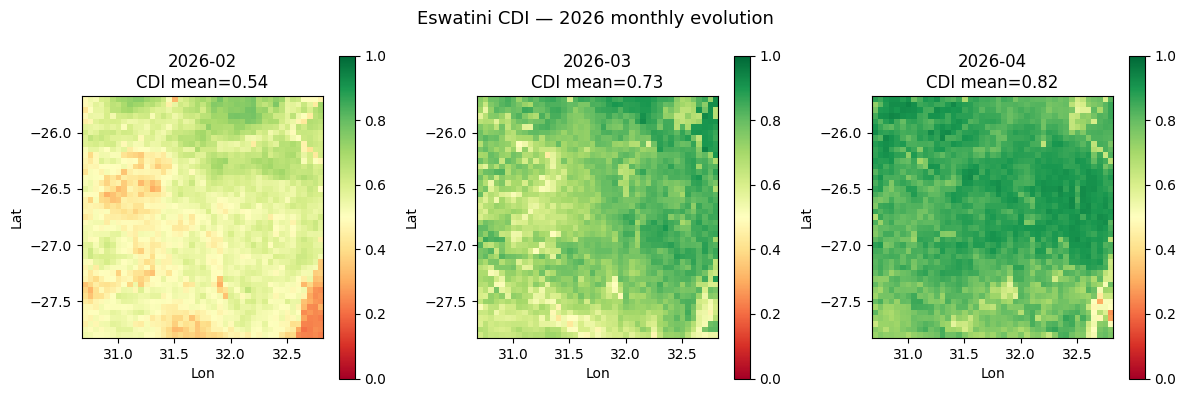

In [11]:
# Plot monthly CDI maps
n = len(monthly_cdi)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]

for ax, ((yr, mo), arr) in zip(axes, monthly_cdi.items()):
    im = ax.imshow(arr, vmin=0, vmax=1, cmap='RdYlGn',
                   extent=extent, origin='upper', aspect='equal')
    ax.set_title(f'{yr}-{mo:02d}\nCDI mean={arr.mean():.2f}')
    ax.set_xlabel('Lon')
    ax.set_ylabel('Lat')
    plt.colorbar(im, ax=ax)

plt.suptitle('Eswatini CDI — 2026 monthly evolution', fontsize=13)
plt.tight_layout()
plt.show()

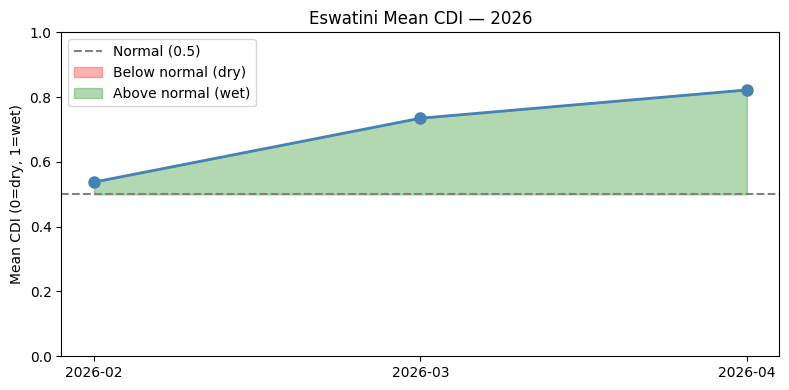

In [12]:
# Time series: mean CDI per month
dates_str = [f'{yr}-{mo:02d}' for yr, mo in monthly_cdi.keys()]
means = [arr.mean() for arr in monthly_cdi.values()]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dates_str, means, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.axhline(0.5, color='gray', linestyle='--', label='Normal (0.5)')
ax.fill_between(dates_str, means, 0.5,
                where=[m < 0.5 for m in means], alpha=0.3, color='red', label='Below normal (dry)')
ax.fill_between(dates_str, means, 0.5,
                where=[m >= 0.5 for m in means], alpha=0.3, color='green', label='Above normal (wet)')
ax.set_ylim(0, 1)
ax.set_ylabel('Mean CDI (0=dry, 1=wet)')
ax.set_title('Eswatini Mean CDI — 2026')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Summary and Validation Checklist

The following table summarises the assumptions the project team has made in processing the NDMC data.
**Please confirm or correct each item.**

| # | Assumption | Confirmed? |
|---|------------|------------|
| 1 | Filename pattern is `{dataset}_{YYYY}-{MM}-01.tif` | ❓ |
| 2 | NoData value is `-1` | ❓ |
| 3 | Values represent percentile rank on a **0–100** scale | ❓ |
| 4 | Scale is uniform across all four datasets (ESI, EVI2, SPI, SM) | ❓ |
| 5 | Higher value = wetter / less stressed (i.e. 100 = most wet) | ❓ |
| 6 | **ESI orientation**: high ESI percentile = low evaporative stress = wet (same polarity as EVI2/SPI/SM, i.e. opposite of the retired LST signal) | ❓ |
| 7 | CRS is EPSG:4326, pixel size 0.05°, no reprojection needed | ❓ |
| 8 | Years 2012–2026 are available for all datasets | ❓ |
| 9 | `chirps_spi_3mn` is the correct SPI variant for a 3-month CDI | ❓ |
| 10 | Proposed CDI weights (ESI 0.3, EVI2 0.3, SPI 0.3, SM 0.1) are reasonable | ❓ |
| 11 | CDI output maps look geographically plausible for Eswatini | ❓ |

> **Note on grid**: This notebook clips with `rasterio.from_bounds` for illustration (≈43×43 px). The production pipeline samples onto a fixed 44×44 grid whose cell centres align exactly with NDMC pixel centres — the values are identical, only the edge handling differs.

---

**Contact**: the maintainer — (contact via repository)

Thank you for your continued support of the Eswatini Drought Map Hub.

In [13]:
# Print a machine-readable summary for the validation report
print('=== PROCESSING ASSUMPTIONS ===')
print(f'NDMC base URL   : {NDMC_BASE}')
print(f'Datasets used   : {", ".join(DATASETS.values())}')
print(f'Eswatini bounds : N={ESWATINI["n_lat"]} S={ESWATINI["s_lat"]} W={ESWATINI["w_lon"]} E={ESWATINI["e_lon"]}')
print(f'NoData (NDMC)   : {NODATA_NDMC}')
print(f'Value scale     : 0–100 (÷100 → 0–1 internally)')
print(f'CDI weights     : {CDI_WEIGHTS}')
print(f'Weight sum      : {sum(CDI_WEIGHTS.values())}')
print()
print('=== SAMPLE DATA STATISTICS ===')
for key, arr in clipped.items():
    v = arr.compressed()
    print(f'{key.upper():5s}: min={v.min():.3f} max={v.max():.3f} '
          f'mean={v.mean():.3f} std={v.std():.3f} n={len(v)}')

=== PROCESSING ASSUMPTIONS ===
NDMC base URL   : https://droughtcenter.unl.edu/Outgoing/Regional_Percentiles/Southern_Africa
Datasets used   : era5_esi_1mn, evi2_1mn, chirps_spi_3mn, noah_soilm_1mn
Eswatini bounds : N=-25.675 S=-27.825 W=30.675 E=32.825
NoData (NDMC)   : -1.0
Value scale     : 0–100 (÷100 → 0–1 internally)
CDI weights     : {'esi': 0.3, 'evi2': 0.3, 'spi': 0.3, 'sm': 0.1}
Weight sum      : 1.0

=== SAMPLE DATA STATISTICS ===
ESI  : min=0.003 max=0.996 mean=0.928 std=0.083 n=1849
EVI2 : min=0.005 max=0.999 mean=0.821 std=0.161 n=1849
SPI  : min=0.382 max=0.942 mean=0.707 std=0.104 n=1849
SM   : min=0.532 max=0.968 mean=0.852 std=0.097 n=1849
